# Reinforcement Learning

# 1. Markov Decision Process

This notebook presents some examples of Markov Decison Processes, where an **agent** interacts with its **environment** and collects **rewards**. 

In all considered models, the reward is attached to the reached **state**. In games for instance, the reward of a state is +1 if you win, -1 if you loose, 0 in all other cases.

Please read the instructions:
* Write concise code and text.
* Check that your notebook runs without errors.

This lab is not graded. You don't have to upload your notebook on Moodle.

In [1]:
import numpy as np

In [2]:
from model import Walk, Maze

Each environment is an object of the class ``Environment`` storing the current state. 

In [3]:
from model import Environment

In [4]:
methods_environment = [method for method in dir(Environment) if '__' not in method]

In [5]:
methods_environment

['decode',
 'display',
 'encode',
 'get_actions',
 'get_all_actions',
 'get_all_states',
 'get_model',
 'get_reward',
 'get_transition',
 'init_state',
 'is_game',
 'is_terminal',
 'reset',
 'show',
 'step']

The agent interacts with the environment and collects rewards.

In [6]:
from agent import Agent

In [7]:
methods_agent = [method for method in dir(Agent) if '__' not in method]

In [8]:
methods_agent

['get_action',
 'get_actions',
 'get_episode',
 'get_returns',
 'one_step_policy',
 'random_policy']

## Walk

We start with a walk in a square. Some states (to be found by the agent) have positive rewards. Some wind (unknown in advance to the agent) might disturb the walk.

In [9]:
environment = Walk()

In [10]:
# show state
environment.show()

|O    |
|     |
|     |
|     |
|     |


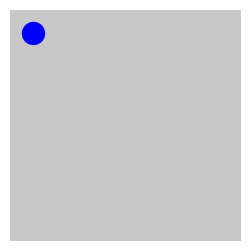

In [11]:
# display state
environment.display()

In [12]:
environment.Size

(5, 5)

In [13]:
# rewards (unknown to the agent)
environment.Rewards

{(1, 1): 1, (1, 3): -1, (3, 1): -1, (3, 3): 3}

In [14]:
# wind (default is none)
environment.Wind

{}

In [15]:
state = environment.state

In [16]:
state

array([0, 0])

In [17]:
environment.get_actions(state)

[(0, 1), (1, 0)]

In [18]:
action = (0, 1)

In [19]:
environment.step(action)

(0, False)

In [20]:
environment.state

array([0, 1])

In [21]:
environment.show()

| O   |
|     |
|     |
|     |
|     |


In [22]:
# agent with random policy (default)
agent = Agent(environment)

In [23]:
state = environment.state
action = agent.get_action(state)

In [24]:
state

array([0, 1])

In [25]:
action

(0, -1)

In [26]:
# interaction with the environment
reward, stop = environment.step(action)

In [27]:
reward

0

In [28]:
stop

False

In [29]:
# all possible actions
agent.get_actions(state)

[(0, 1), (0, -1), (1, 0)]

In [30]:
# policy of the agent
probs, actions = agent.policy(state)

In [31]:
print(probs)

[0.33333333 0.33333333 0.33333333]


In [32]:
print(actions)

[(0, 1), (0, -1), (1, 0)]


In [33]:
# an episode
stop, states, rewards = agent.get_episode(horizon=50)

In [34]:
# the episode includes the initial state
len(states)

51

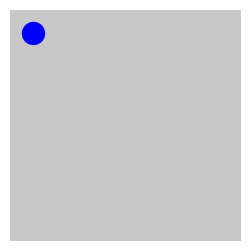

In [35]:
# display the episode
animation = environment.display(states)

In [36]:
animation

In [37]:
# rewards are attached to the reached states
len(rewards)

50

In [38]:
# total reward
print(np.sum(rewards))

1


In [39]:
# discounted reward
gamma = 0.9
weights = np.power(gamma, np.arange(len(rewards)))
print(np.sum(rewards * weights))

-0.5079702221142255


## To do

* Compute the expected return at time horizon $t=2$ with discount factor $\gamma=0.9$.
* Check your result by simulation.

In [40]:
# returns over several episodes
returns = agent.get_returns(n_episodes=10, horizon=100, gamma=gamma)

In [41]:
n_episodes = 10000
horizon = 2
gamma = 0.9

In [42]:
returns_t2 = []

for _ in range(n_episodes):
    stop, states, rewards = agent.get_episode(horizon=horizon)
    R2 = rewards[0] + rewards[1] * gamma
    returns_t2.append(R2)

print("Estimation simulée de E[R2] :", np.mean(returns_t2))

Estimation simulée de E[R2] : 0.29574000000000006


In [43]:
returns = agent.get_returns(n_episodes=n_episodes, horizon=horizon, gamma=gamma)
print(np.mean(returns))

0.2979


## Weighted random policy

We now explore a random policy where the moves are proportional to some fixed weights.

In [44]:
weights = {(0, 1): 2, (1, 0): 2, (0, -1): 1, (-1, 0): 1}

In [45]:
def weighted_random_policy(state):
    """Weighted random policy. 
    Each action is selected in proportion to its weight. 
    If the weights of available actions are all zero, take uniform choice among these actions."""
    actions = Walk().get_actions(state)
    # to be modified
    local_weights = [weights.get(a, 0) for a in actions]

    total_weight = sum(local_weights)
    n = len(actions)

    if total_weight == 0:
        probs = [1/n for _ in range(n)]
    else:
        probs = [w / total_weight for w in local_weights]
    return probs, actions

## To do

* Code and test the function ``weighted_random_policy``. 
* Is this policy better than the pure random policy at time horizon $t=100$? <br>Explain the results.

In [46]:
horizon = 100
agent = Agent(environment, policy=weighted_random_policy)
stop, states, rewards = agent.get_episode(horizon=horizon)
print(sum(rewards))

27


In [47]:
agent = Agent(environment)
stop, states, rewards = agent.get_episode(horizon=horizon)
print(sum(rewards))

3


ANSWER:

C'est la fonction weights qui explique cette différence.

Ce qui signifie :
- aller vers le haut (0, 1) → poids 2
- aller vers la droite (1, 0) → poids 2
- aller vers le bas (0, -1) → poids 1
- aller vers la gauche (-1, 0) → poids 1

Donc l’agent préfère fortement se déplacer vers le haut et vers la droite.

Et dans l’environnement Walk :
- les récompenses +1 sont en haut à droite
- les punitions -1 ne sont pas dans cette direction
- se déplacer vers le haut/droite augmente les chances de toucher des rewards

Ta politique pondérée dirige donc naturellement l’agent vers les zones positives.

## Maze

Now let's try to escape a maze!

In [48]:
maze_map = np.load('maze.npy')

In [49]:
init_state = (1, 0)
exit_state = (1, 20)
Maze.set_parameters(maze_map, init_state, [exit_state])

In [50]:
environment = Maze()

In [51]:
environment.show()

+++++++++++++++++++++
O       +         +  
+ +++ +++ +++ +++ + +
+   +       + + + + +
+ +++ +++ + +++ + + +
+ +   + + +       + +
+ +++++ + +++ + +++ +
+       +     + +   +
+ + +++ +++++++ +++ +
+            +      +
+++++++++++++++++++++


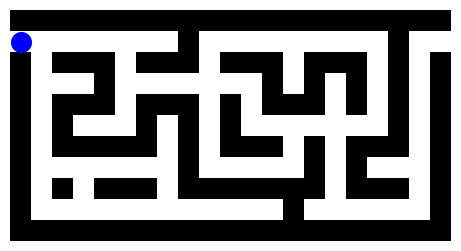

In [52]:
environment.display()

In [53]:
environment.state

array([1, 0])

In [54]:
state = environment.state
reward = environment.get_reward(state)

In [55]:
# -1 in any state except the exit
reward

-1

In [56]:
environment.get_actions(state)

[(0, 1)]

In [57]:
action = (0, 1)

In [58]:
environment.step(action)

(-1, False)

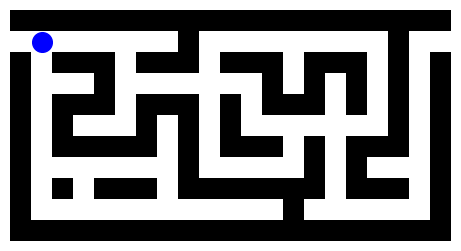

In [59]:
environment.display()

In [60]:
# agent with random policy
agent = Agent(environment)

In [61]:
stop, states, rewards = agent.get_episode(horizon=250)

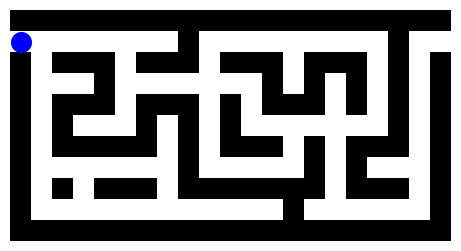

In [62]:
animation = environment.display(states)

In [63]:
animation

In [64]:
# time in the Maze
print(-np.sum(rewards))

250


## To do

* Test the weighted random policy.
* Are there weights for which you can escape the maze in less than 250 steps with probability higher than 10%?

In [66]:
def weighted_random_policy(state):
    actions = Maze().get_actions(state)
    local_weights = [weights.get(a, 0) for a in actions]
    total = sum(local_weights)
    n = len(actions)
    if total == 0:
        probs = [1/n for _ in range(n)]
    else:
        probs = [w/total for w in local_weights]
    return probs, actions

In [68]:
horizon = 250
agent = Agent(environment, policy=weighted_random_policy)
stop, states, rewards = agent.get_episode(horizon=horizon)
print(sum(rewards))

-250


In [79]:
weights = {(0,1): 6, (1,0): 6, (0,-1): 1, (-1,0): 1}

In [80]:
def escape_probability(policy, n_episodes=200, horizon=250):
    n_escape = 0
    for _ in range(n_episodes):
        agent = Agent(environment, policy=policy)
        stop, states, rewards = agent.get_episode(horizon=horizon)
        if stop:
            n_escape += 1
    return n_escape / n_episodes

p = escape_probability(weighted_random_policy, n_episodes=300, horizon=250)
print("Escape probability =", p)

Escape probability = 0.0


ANSWER:

Même un très gros poids sur “droite” ou “bas” NE SUFFIT PAS parce que le maze nécessite parfois de monter, revenir en arrière, puis redescendre

Aucune weighted random policy simple ne peut dépasser 10% de succès sur ce maze.

## Games

Finally, let's play games!<br>
Note that in most games:
* you play against an adversary (which is part of the environment),
* you may play first or second,
* when your adversary plays, you have only one possible action (let your adversary play),
* you can also impose an action to your adversary (useful for training).



We here consider [Tic-Tac-Toe](https://en.wikipedia.org/wiki/Tic-tac-toe), [Nim](https://en.wikipedia.org/wiki/Nim), [Connect Four](https://en.wikipedia.org/wiki/Connect_Four) and [Five in a row](https://en.wikipedia.org/wiki/Gomoku).
Feel free to add more :-)

In [81]:
from model import TicTacToe, Nim, ConnectFour, FiveInRow

Each game is an object of the class ``Game``. 

In [82]:
from model import Game

In [83]:
methods_game = [method for method in dir(Game) if '__' not in method]

In [84]:
methods_game

['Board_Size',
 'decode',
 'display',
 'encode',
 'get_actions',
 'get_all_actions',
 'get_all_states',
 'get_available_actions',
 'get_model',
 'get_next_state',
 'get_reward',
 'get_transition',
 'init_state',
 'is_game',
 'is_terminal',
 'reset',
 'show',
 'step']

In [85]:
set(methods_game) - set(methods_environment)

{'Board_Size', 'get_available_actions', 'get_next_state'}

The method ``get_next_state`` allows you to get the next state for any (state, action) pair, without modifying the current state. This will be useful to learn good policies.

The method ``get_available_actions`` gives the available actions, ignoring the player.

## Tic-Tac-Toe

We start with Tic-Tac-Toe.

### Play first

In [86]:
# game against a random player (default)
game = TicTacToe()

In [87]:
game.show()

|   |
|   |
|   |


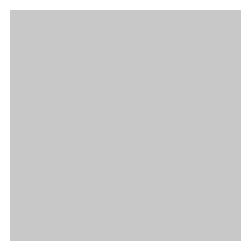

In [88]:
game.display()

In [89]:
# next player, board
game.state

(1,
 array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]))

In [90]:
# your possible actions
game.get_actions(game.state)

[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]

In [91]:
# next state given some move
game.get_next_state(game.state, (1,1))

(-1,
 array([[0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]]))

In [92]:
# the state is not modified
game.state

(1,
 array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]))

In [93]:
# you play at random (default)
agent = Agent(game)

In [94]:
# you play as player 1 (default)
agent.player

1

In [95]:
# your adversary plays as player -1
game.adversary.player

-1

In [96]:
state = game.state
action = agent.get_action(state)

In [97]:
action

(2, 2)

In [98]:
reward, stop = game.step(action)

In [99]:
game.show()

|   |
|   |
|  X|


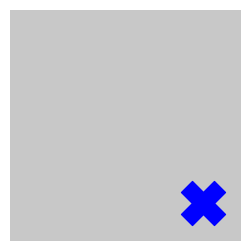

In [100]:
# you're blue
game.display()

In [101]:
game.state

(-1,
 array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 1]]))

In [102]:
# your moves
game.get_actions(game.state)

['pass']

In [103]:
# possible moves of your adversary
game.get_available_actions(game.state)

[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1)]

In [104]:
# your actual move
action = agent.get_action(game.state)

In [105]:
print(action)

pass


In [106]:
reward, stop = game.step(action)

In [107]:
game.show()

|   |
|  O|
|  X|


In [108]:
stop, states, rewards = agent.get_episode()

In [109]:
game.show()

|OXO|
| OX|
|OXX|


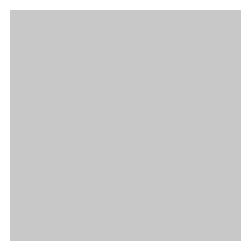

In [110]:
animation = game.display(states)

In [115]:
animation

In [116]:
rewards

[0, 0, 0, 0, 0, 0, 0, -1]

In [117]:
returns = agent.get_returns()
np.unique(agent.get_returns(), return_counts=True)

(array([-1,  0,  1]), array([35, 17, 48]))

### Play second

In [118]:
# your adversary starts
game = TicTacToe(play_first=False)

In [119]:
game.first_player

-1

In [120]:
# you still play at random
agent = Agent(game)

In [121]:
stop, states, rewards = agent.get_episode()

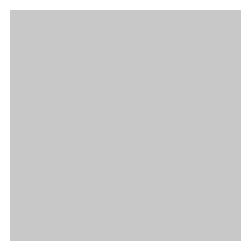

In [122]:
animation = game.display(states)

In [123]:
# you're still blue, red starts
animation

In [124]:
rewards

[0, 0, 0, 0, 0, 1]

In [125]:
returns = agent.get_returns()
np.unique(agent.get_returns(), return_counts=True)

(array([-1,  0,  1]), array([60, 12, 28]))

### Control your adversary

You can force the actions of your adversary (useful for training).

In [126]:
game = TicTacToe()

In [127]:
actions = [(0, 0), (1, 1), (0, 2),  (2, 2), (0, 1)]

In [128]:
for action in actions:
    game.step(action)

In [129]:
game.show()

|XXX|
| O |
|  O|


### One step ahead

In [130]:
# your adversary is random
game = TicTacToe()

In [131]:
# you play with one-step ahead policy
agent = Agent(game, policy='one_step')

In [132]:
stop, states, rewards = agent.get_episode()

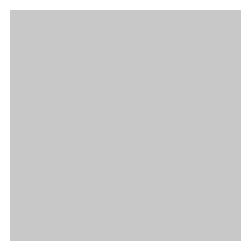

In [133]:
animation = game.display(states)

In [134]:
animation

In [135]:
returns = agent.get_returns()
np.unique(agent.get_returns(), return_counts=True)

(array([-1,  0,  1]), array([ 1,  7, 92]))

In [136]:
# your adversary also looks one-step ahead
game = TicTacToe(adversary_policy='one_step')

In [137]:
agent = Agent(game, policy='one_step')

In [138]:
stop, states, rewards = agent.get_episode()

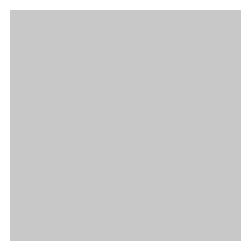

In [139]:
animation = game.display(states)

In [140]:
animation

In [141]:
returns = agent.get_returns()
np.unique(returns, return_counts=True)

(array([-1,  0,  1]), array([20, 51, 29]))

## Nim

### Random players

In [142]:
# game against a random player (default)
game = Nim()

In [143]:
game.state

(1, array([1, 3, 5, 7]))

In [144]:
game.show()

|
|||
|||||
|||||||


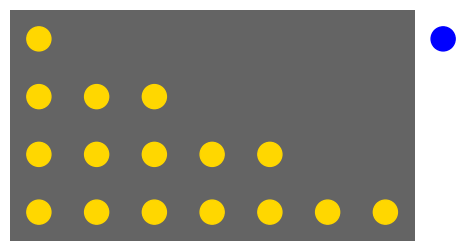

In [145]:
# you're the blue player
game.display()

In [146]:
# player, board
game.state

(1, array([1, 3, 5, 7]))

In [147]:
# you play at random
agent = Agent(game)

In [148]:
state = game.state
action = agent.get_action(state)

In [149]:
action

(1, 2)

In [150]:
reward, stop = game.step(action)

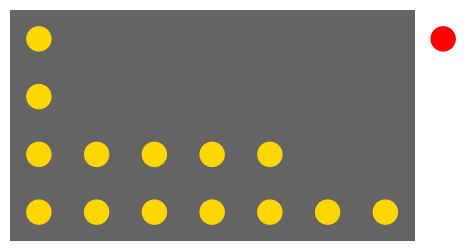

In [151]:
game.display()

In [152]:
stop, states, rewards = agent.get_episode()

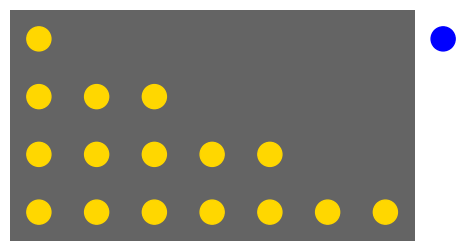

In [153]:
animation = game.display(states)

In [154]:
animation

In [155]:
rewards

[0, 0, 0, 0, 0, 1]

In [156]:
returns = agent.get_returns()
np.unique(returns, return_counts=True)

(array([-1,  1]), array([56, 44]))

### One step ahead

In [157]:
game = Nim(adversary_policy='one_step')

In [158]:
agent = Agent(game, policy='one_step')

In [159]:
returns = agent.get_returns()
np.unique(returns, return_counts=True)

(array([-1,  1]), array([47, 53]))

## Connect Four

### Random players

In [161]:
# game against a random player
game = ConnectFour()

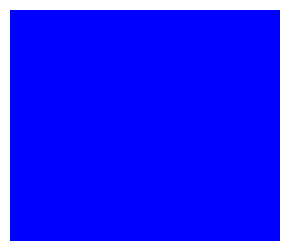

In [162]:
game.display()

In [163]:
game.state

(1,
 array([[0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0]]))

In [164]:
# you play at random
agent = Agent(game)

In [165]:
stop, states, rewards = agent.get_episode()

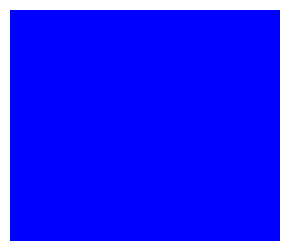

In [166]:
animation = game.display(states)

In [170]:
# you play yellow
animation

In [171]:
returns = agent.get_returns(n_episodes=10)
np.unique(returns, return_counts=True)

(array([-1,  1]), array([5, 5]))

### One step ahead

In [172]:
game = ConnectFour(adversary_policy='one_step')

In [173]:
agent = Agent(game, policy='one_step')

In [174]:
stop, states, rewards = agent.get_episode()

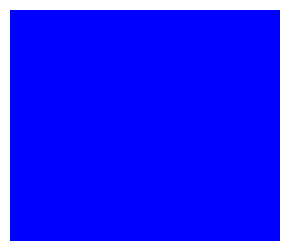

In [175]:
animation = game.display(states)

In [176]:
animation

In [177]:
returns = agent.get_returns(n_episodes=10)
np.unique(returns, return_counts=True)

(array([-1,  1]), array([5, 5]))

## Five-in-a-row

### Random players

In [178]:
game = FiveInRow()

In [179]:
game.show()

|          |
|          |
|          |
|          |
|          |
|          |
|          |
|          |
|          |
|          |


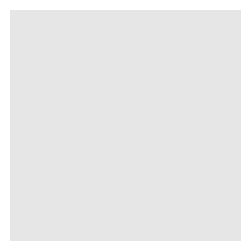

In [180]:
game.display()

In [181]:
agent = Agent(game)

In [182]:
stop, states, rewards = agent.get_episode()

In [183]:
game.show()

|XO X  OXXO|
|O O XOOOOX|
|OXOO  XXXO|
|  XOO OX O|
|OO XX   OX|
|OXOX O  X |
|X XXXXXX X|
|  O   XO X|
|OO O     X|
|XXOO X  O |


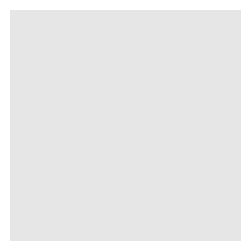

In [184]:
animation = game.display(states)

In [185]:
animation

In [186]:
returns = agent.get_returns(n_episodes=10)
np.unique(returns, return_counts=True)

(array([-1,  1]), array([7, 3]))

### One step ahead

In [187]:
game = FiveInRow()

In [188]:
agent = Agent(game, policy='one_step')

In [189]:
returns = agent.get_returns(n_episodes=5)
np.unique(returns, return_counts=True)

(array([-1,  1]), array([1, 4]))

In [190]:
# a stronger adversary
game = FiveInRow(adversary_policy='one_step')

In [191]:
agent = Agent(game, policy='one_step')

In [192]:
returns = agent.get_returns(n_episodes=5)
np.unique(returns, return_counts=True)

(array([-1,  1]), array([4, 1]))

## Value function

The value function of a policy can be computed from Bellman's equation, provided the state space is not too large.

You can check this condition by listing all states.

In [193]:
environment = Maze()

In [194]:
len(environment.get_all_states())

105

## To do

* Complete the method ``evaluate_policy`` of the class ``PolicyEvaluation`` (Bellman's equation)
* Display the value function of the random policy in the maze with discount factor $\gamma=1$. Interpret the result.
* What is the value of the initial state?
* Adapt the parameter ``n_eval`` and deduce the actual value of the initial state.
* How many steps are necessary for a random agent to escape the maze?

In [195]:
# we use sparse transition matrices
from scipy import sparse

In [241]:
class PolicyEvaluation:
    """Evaluation of a policy by dynamic programming.
    
    Parameters
    ----------
    environment : object of class Environment
        Environment of the agent.
    policy : function
        Policy of the agent.
    player : int
        Player for games (1 or -1, default = default player of the game).
    gamma : float
        Discount factor (between 0 and 1).
    n_eval : int
        Number of iterations of Bellman's equation for policy evaluation.
    """
    def __init__(self, environment, policy='random', player=None, gamma=1, n_eval=100):
        self.environment = environment
        agent = Agent(environment, policy, player)
        self.policy = agent.policy
        self.player = agent.player
        self.gamma = gamma
        self.n_eval = n_eval
        self.index_states()
        if self.n_states == 0:
            raise ValueError("Not applicable. The state space is too large.")
        self.get_rewards()
        self.get_transitions()
        
    def index_states(self):
        """Index all states."""
        self.states = self.environment.get_all_states()
        self.n_states = len(self.states)
        self.state_id = {self.environment.encode(state): i for i, state in enumerate(self.states)}
        
    def get_state_id(self, state):
        return self.state_id[self.environment.encode(state)]

    def get_rewards(self):
        """Get the reward of each state."""
        rewards = np.zeros(self.n_states)
        for i, state in enumerate(self.states):    
            rewards[i] = self.environment.get_reward(state)
        self.rewards = rewards
        
    def get_actions(self, state, player=None):
        if self.environment.is_game():
            if player is None:
                player = self.player
            actions = self.environment.get_actions(state, player)
        else:
            actions = self.environment.get_actions(state)
        return actions
    
    def get_transitions(self):
        """Get the transitions (probabilities to move from one state to another) for each action."""
        actions = self.environment.get_all_actions()
        transitions = {action: sparse.lil_matrix((self.n_states, self.n_states)) for action in actions}
        for i, state in enumerate(self.states):    
            actions = self.get_actions(state)
            for action in actions:
                probs, next_states = self.environment.get_transition(state, action)
                indices = np.array([self.get_state_id(next_state) for next_state in next_states])
                transitions[action][i, indices] = np.array(probs)
        self.transitions = {action: sparse.csr_matrix(transition) for action, transition in transitions.items()}
            
    def evaluate_policy(self):
        """Evaluate a policy by iteration of Bellman's equation."""
        transitions = self.transitions
        # probability of each action over the states
        probs = {action: np.zeros(self.n_states) for action in transitions}
        for state in self.states:    
            i = self.get_state_id(state)
            for prob, action in zip(*self.policy(state)):
                probs[action][i] = prob
        # Bellman's equation
        values = np.zeros(self.n_states)

        for t in range(self.n_eval):
            # values of reached states
            old_values = values.copy()      # ← indispensable !
            new_values = np.zeros(self.n_states)

            for action, transition in transitions.items():
                # Bellman update : π(a|s) * ( R(s) + γ * Σ P(s'|s,a) V_old(s') )
                new_values += probs[action] * ( self.rewards + self.gamma * transition.dot(old_values) )

            values = new_values

        self.values = values
     
   

In [242]:
environment = Maze()

In [243]:
agent = Agent(environment)
random_policy = agent.policy

In [244]:
algo = PolicyEvaluation(environment, random_policy)

In [245]:
algo.evaluate_policy()

In [246]:
values = algo.values

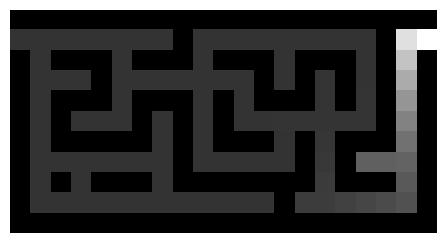

In [247]:
environment.display_values(values)

In [248]:
# value of the initial state
state = environment.init_state()
i = algo.get_state_id(state)
print(values[i])

-99.99978329424528


## To do

We now consider the walk, first in the absence of wind.

* Display the value function of the random policy with discount factor $\gamma=0.9$.
* What are the states of highest value? Interpret the results.
* Check the value of the initial state by simulation.
* Observe the impact of the wind on the value function. Interpret the result.


In [258]:
# no wind
environment = Walk()
print(environment.Wind)

{(0, 1): 0.8}


In [259]:
def estimate_value_function(environment, gamma=0.9, horizon=100, n_episodes=2000):
    V = {}
    agent = Agent(environment)

    for s in environment.get_all_states():
        s = tuple(s)  # ← FIX : garantir que la clé est un tuple (hashable)
        
        returns = []
        for _ in range(n_episodes):
            environment.state = np.array(s)
            G = 0
            discount = 1
            stop = False

            for t in range(horizon):
                if stop:
                    break
                action = agent.get_action(environment.state)
                reward, stop = environment.step(action)
                G += discount * reward
                discount *= gamma

            returns.append(G)

        V[s] = np.mean(returns)

    return V


In [260]:
environment = Walk()
V_no_wind = estimate_value_function(environment)

print("Top value states (no wind):")
print(sorted(V_no_wind.items(), key=lambda x: -x[1])[:5])

s0 = (0, 0)
print("Estimated V(s0):", V_no_wind[s0])

Top value states (no wind):
[((np.int64(4), np.int64(2)), np.float64(1.9555289377261769)), ((np.int64(3), np.int64(1)), np.float64(1.5276417445314048)), ((np.int64(3), np.int64(3)), np.float64(1.3706872237596)), ((np.int64(4), np.int64(3)), np.float64(1.0707412294972625)), ((np.int64(4), np.int64(0)), np.float64(1.0592185161563419))]
Estimated V(s0): 0.3514464879416041


In [261]:
# strong wind
wind = {(0, 1): 0.8}
Walk.set_parameters(Walk.Size, Walk.Rewards, wind)
environment = Walk()
V_wind = estimate_value_function(environment)

print("\nTop value states (wind):")
print(sorted(V_wind.items(), key=lambda x: -x[1])[:5])

# Compare initial state
print("V(s0) no wind:", V_no_wind[s0])
print("V(s0) wind   :", V_wind[s0])


Top value states (wind):
[((np.int64(4), np.int64(2)), np.float64(1.9356571226133137)), ((np.int64(3), np.int64(1)), np.float64(1.5647030789729457)), ((np.int64(3), np.int64(3)), np.float64(1.3185377609666509)), ((np.int64(4), np.int64(3)), np.float64(1.0921659183515957)), ((np.int64(3), np.int64(2)), np.float64(1.0143986817649722))]
V(s0) no wind: 0.3514464879416041
V(s0) wind   : 0.4277555168424981


In [262]:
environment = Walk()
print(environment.Wind)

{(0, 1): 0.8}


## To do

We now consider games.

* Evaluate the random policy and the one-step policy against a random adversary when possible (i.e., state space not too large).
* Do the same when the adversary plays with the one-step policy.
* Predict some first good moves in this case.

In [276]:
Game = TicTacToe
game = Game()

In [277]:
algo = PolicyEvaluation(game)

In [278]:
def value_dict(algo):
    """Retourne {state : value} où state est encodé comme dans PolicyEvaluation."""
    V = {}
    for i, state in enumerate(algo.states):
        key = algo.environment.encode(state)
        V[key] = algo.values[i]
    return V

In [280]:
from model import TicTacToe
from agent import Agent

print("=== Random Policy vs Random Adversary ===")

game = TicTacToe()
algo = PolicyEvaluation(game, policy='random', gamma=0.9, n_eval=200)
algo.evaluate_policy()

V_random = value_dict(algo)

init_state = game.state       # état initial du jeu
init = algo.environment.encode(init_state)
print("Value of initial state:", V_random[init])


=== Random Policy vs Random Adversary ===
Value of initial state: 0.26996752902857146


In [281]:
from model import TicTacToe
from agent import Agent
from scipy import sparse
import numpy as np

print("\n=== One-Step Policy vs Random Adversary ===")

# Jeu : adversaire aléatoire
game = TicTacToe(adversary_policy='random')

# Agent utilisant la politique one_step
algo = PolicyEvaluation(game, policy='one_step', gamma=1, n_eval=200)
algo.evaluate_policy()

# Convertir tableau en dict {encoded_state : value}
V_one = value_dict(algo)

# État initial encodé
init_state = game.state
init = algo.environment.encode(init_state)

print("Value of initial state (One-Step vs Random):", V_one[init])


=== One-Step Policy vs Random Adversary ===
Value of initial state (One-Step vs Random): 0.8824514991181656


In [282]:
print("\n=== One-Step Policy vs One-Step Adversary ===")

# Le joueur ET l'adversaire jouent en one_step
game = TicTacToe(adversary_policy='one_step')

algo = PolicyEvaluation(game, policy='one_step', gamma=1, n_eval=200)
algo.evaluate_policy()

V_one_vs_one = value_dict(algo)

# état initial encodé
init_state = game.state
init = algo.environment.encode(init_state)

print("Value of initial state (One-Step vs One-Step):", V_one_vs_one[init])



=== One-Step Policy vs One-Step Adversary ===
Value of initial state (One-Step vs One-Step): 0.13756613756613756


In [ ]:
print("\n=== Best First Moves Under One-Step Policy ===")

game = TicTacToe(adversary_policy='one_step')
algo = PolicyEvaluation(game, policy='one_step', gamma=1, n_eval=200)
algo.evaluate_policy()
V = value_dict(algo)

initial_state = game.state
actions = game.get_actions(initial_state)

moves = []
for a in actions:
    s2 = game.get_next_state(initial_state, a)
    key = algo.environment.encode(s2)
    moves.append((a, V.get(key, 0)))

# trier décroissant
moves_sorted = sorted(moves, key=lambda x: -x[1])

print("Moves sorted by predicted value:")
for move, val in moves_sorted:
    print(move, "→", round(val, 3))


=== Best First Moves Under One-Step Policy ===
Moves sorted by predicted value:
(1, 1) → 0.258
(2, 0) → 0.235
(0, 0) → 0.235
(0, 2) → 0.235
(2, 2) → 0.235
(2, 1) → 0.01
(1, 2) → 0.01
(1, 0) → 0.01
(0, 1) → 0.01
